# Trader Performance vs Market Sentiment Analysis

## Objective
Analyze how Bitcoin market sentiment (Fear & Greed Index) influences trader behavior and performance on the Hyperliquid platform. By merging sentiment data with historical trade records, we identify patterns in profitability, position sizing, and risk behavior.

## Datasets
- **`fear_greed_index.csv`** — Daily market sentiment classification (Extreme Fear → Extreme Greed)
- **`historical_data.csv`** — Hyperliquid trade records: price, size, direction, PnL, timestamps

## Workflow
1. Load & inspect data
2. Clean & preprocess
3. Merge datasets on date
4. Compute performance metrics
5. Visualize & interpret results

---
## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

# Sentiment category order for consistent plot ordering
SENTIMENT_ORDER = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
SENTIMENT_COLORS = {
    "Extreme Fear": "#d73027",
    "Fear":         "#fc8d59",
    "Neutral":      "#fee090",
    "Greed":        "#91bfdb",
    "Extreme Greed":"#4575b4",
}

---
## 2. Load Data

In [3]:
# Load raw CSV files
sentiment_raw = pd.read_csv('fear_greed_index.csv')
trades_raw    = pd.read_csv('historical_data.csv')

print(f"Sentiment dataset : {sentiment_raw.shape[0]:,} rows × {sentiment_raw.shape[1]} columns")
print(f"Trades dataset    : {trades_raw.shape[0]:,} rows × {trades_raw.shape[1]} columns")

Sentiment dataset : 2,644 rows × 4 columns
Trades dataset    : 211,224 rows × 16 columns


### 2.1 Quick look at the sentiment data

In [4]:
sentiment_raw.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


### 2.2 Quick look at the trade data

In [5]:
trades_raw.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


---
## 3. Data Quality Check

In [6]:
def data_quality_report(df: pd.DataFrame, name: str) -> None:
    """Print a concise quality summary for a DataFrame."""
    print(f"{'='*50}")
    print(f"  Dataset: {name}")
    print(f"{'='*50}")
    print(f"  Shape       : {df.shape}")
    print(f"  Duplicates  : {df.duplicated().sum()}")
    print("  Missing values per column:")
    missing = df.isnull().sum()
    for col, count in missing.items():
        flag = " ⚠️" if count > 0 else ""
        print(f"    {col:<25} {count}{flag}")
    print()

data_quality_report(sentiment_raw, "Fear & Greed Index")
data_quality_report(trades_raw,    "Hyperliquid Trades")

  Dataset: Fear & Greed Index
  Shape       : (2644, 4)
  Duplicates  : 0
  Missing values per column:
    timestamp                 0
    value                     0
    classification            0
    date                      0

  Dataset: Hyperliquid Trades
  Shape       : (211224, 16)
  Duplicates  : 0
  Missing values per column:
    Account                   0
    Coin                      0
    Execution Price           0
    Size Tokens               0
    Size USD                  0
    Side                      0
    Timestamp IST             0
    Start Position            0
    Direction                 0
    Closed PnL                0
    Transaction Hash          0
    Order ID                  0
    Crossed                   0
    Fee                       0
    Trade ID                  0
    Timestamp                 0



> **Result:** Both datasets are complete — no missing values, no duplicate rows. No imputation needed.

---
## 4. Preprocessing & Date Alignment

In [7]:
# Working copies
sentiment = sentiment_raw.copy()
trades    = trades_raw.copy()

# Sentiment: parse date column
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

# Trades: convert Unix-ms timestamp → datetime, then extract date
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')
trades['date']      = trades['Timestamp'].dt.date

print("Date ranges")
print(f"  Sentiment : {sentiment['date'].min()}  →  {sentiment['date'].max()}")
print(f"  Trades    : {trades['date'].min()}  →  {trades['date'].max()}")

Date ranges
  Sentiment : 2018-02-01  →  2025-05-02
  Trades    : 2023-03-28  →  2025-06-15


---
## 5. Merge Datasets

In [8]:
# Left-join: every trade gets the sentiment label for that day.
# Trades on days with no sentiment data will have NaN (kept for transparency).
merged = pd.merge(
    trades,
    sentiment[['date', 'value', 'classification']],
    on='date',
    how='left'
)

unmatched = merged['classification'].isna().sum()
print(f"Merged shape       : {merged.shape}")
print(f"Trades w/o sentiment label : {unmatched} ({unmatched/len(merged)*100:.1f}%)")

merged.head()

Merged shape       : (211224, 19)
Trades w/o sentiment label : 26961 (12.8%)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,74.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,74.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,74.0,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,74.0,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,74.0,Greed


---
## 6. Feature Engineering

In [9]:
# Binary win flag: PnL > 0
merged['is_win'] = merged['Closed PnL'] > 0

# Drop rows with no sentiment (cannot be classified)
merged_clean = merged.dropna(subset=['classification']).copy()

# Enforce ordered categorical for consistent plot ordering
merged_clean['classification'] = pd.Categorical(
    merged_clean['classification'],
    categories=SENTIMENT_ORDER,
    ordered=True
)

print(f"Rows used for analysis : {len(merged_clean):,}")
print("\nTrades per sentiment class:")
print(merged_clean['classification'].value_counts().sort_index())

Rows used for analysis : 184,263

Trades per sentiment class:
classification
Extreme Fear          0
Fear             133871
Neutral            7141
Greed             36289
Extreme Greed      6962
Name: count, dtype: int64


---
## 7. Aggregate Metrics by Sentiment

In [10]:
summary = (
    merged_clean
    .groupby('classification', observed=True)
    .agg(
        trade_count   = ('Closed PnL', 'count'),
        win_rate      = ('is_win',      'mean'),
        avg_pnl       = ('Closed PnL',  'mean'),
        median_pnl    = ('Closed PnL',  'median'),
        avg_size_usd  = ('Size USD',    'mean'),
    )
    .reset_index()
)

summary['win_rate_pct'] = (summary['win_rate'] * 100).round(2)
summary['avg_pnl']      = summary['avg_pnl'].round(2)
summary['avg_size_usd'] = summary['avg_size_usd'].round(2)

print(summary.to_string(index=False))

classification  trade_count  win_rate  avg_pnl  median_pnl  avg_size_usd  win_rate_pct
          Fear       133871  0.415146    50.05         0.0       5259.98         41.51
       Neutral         7141  0.317182    22.23         0.0       3058.85         31.72
         Greed        36289  0.446471    87.89         0.0       3182.88         44.65
 Extreme Greed         6962  0.490089    25.42         0.0       5660.27         49.01


---
## 8. Visualizations

### 8.1 Win Rate by Market Sentiment

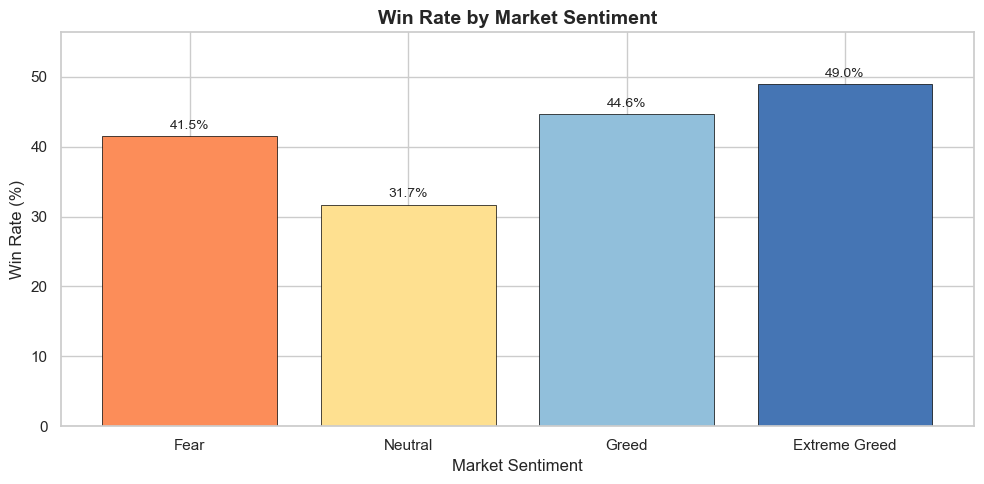

In [11]:
fig, ax = plt.subplots()
bars = ax.bar(
    summary['classification'],
    summary['win_rate_pct'],
    color=[SENTIMENT_COLORS[s] for s in summary['classification']],
    edgecolor='black', linewidth=0.5
)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=10)
ax.set_title('Win Rate by Market Sentiment', fontweight='bold')
ax.set_xlabel('Market Sentiment')
ax.set_ylabel('Win Rate (%)')
ax.set_ylim(0, summary['win_rate_pct'].max() * 1.15)
plt.tight_layout()
plt.show()

### 8.2 Average Closed PnL by Market Sentiment

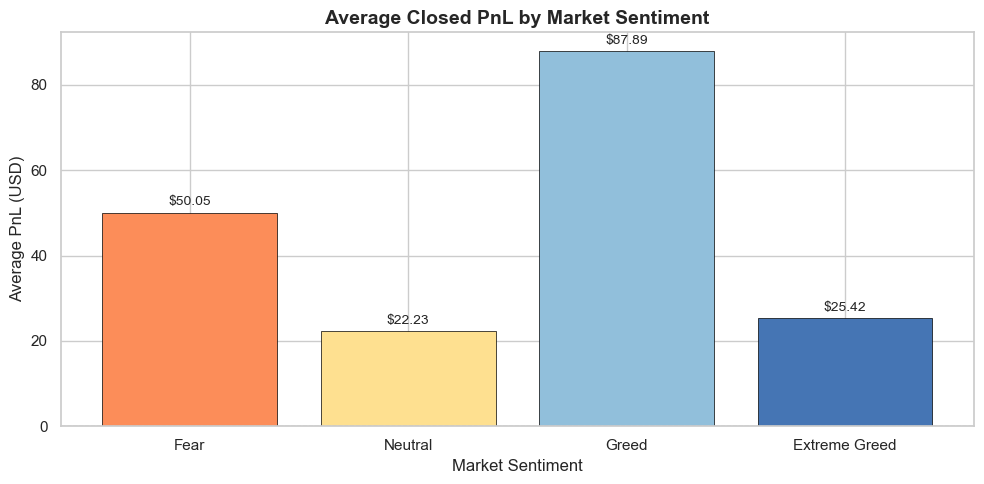

In [12]:
fig, ax = plt.subplots()
bars = ax.bar(
    summary['classification'],
    summary['avg_pnl'],
    color=[SENTIMENT_COLORS[s] for s in summary['classification']],
    edgecolor='black', linewidth=0.5
)
ax.bar_label(bars, fmt='$%.2f', padding=3, fontsize=10)
ax.set_title('Average Closed PnL by Market Sentiment', fontweight='bold')
ax.set_xlabel('Market Sentiment')
ax.set_ylabel('Average PnL (USD)')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

### 8.3 Average Trade Size (USD) by Market Sentiment

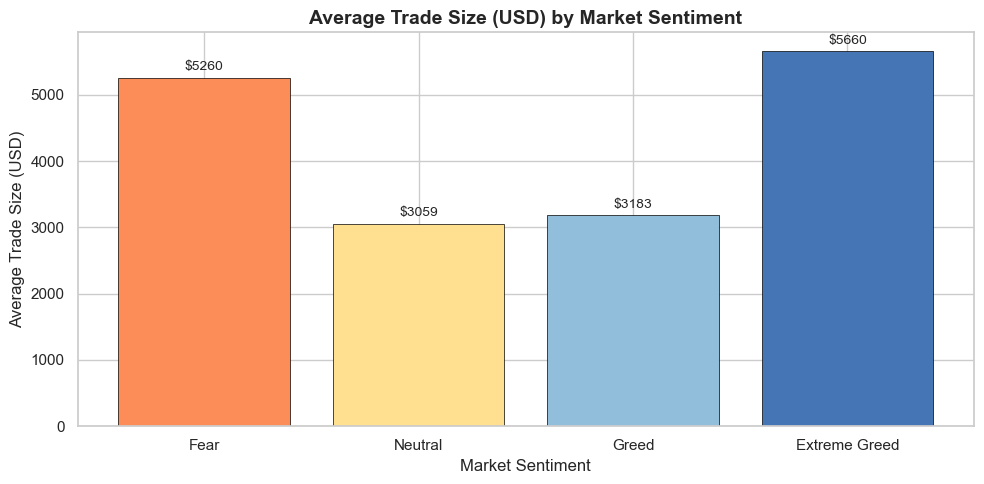

In [13]:
fig, ax = plt.subplots()
bars = ax.bar(
    summary['classification'],
    summary['avg_size_usd'],
    color=[SENTIMENT_COLORS[s] for s in summary['classification']],
    edgecolor='black', linewidth=0.5
)
ax.bar_label(bars, fmt='$%.0f', padding=3, fontsize=10)
ax.set_title('Average Trade Size (USD) by Market Sentiment', fontweight='bold')
ax.set_xlabel('Market Sentiment')
ax.set_ylabel('Average Trade Size (USD)')
plt.tight_layout()
plt.show()

### 8.4 PnL Distribution by Market Sentiment (Box Plot)

C:\Users\arham\AppData\Local\Temp\ipykernel_18748\4186033949.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


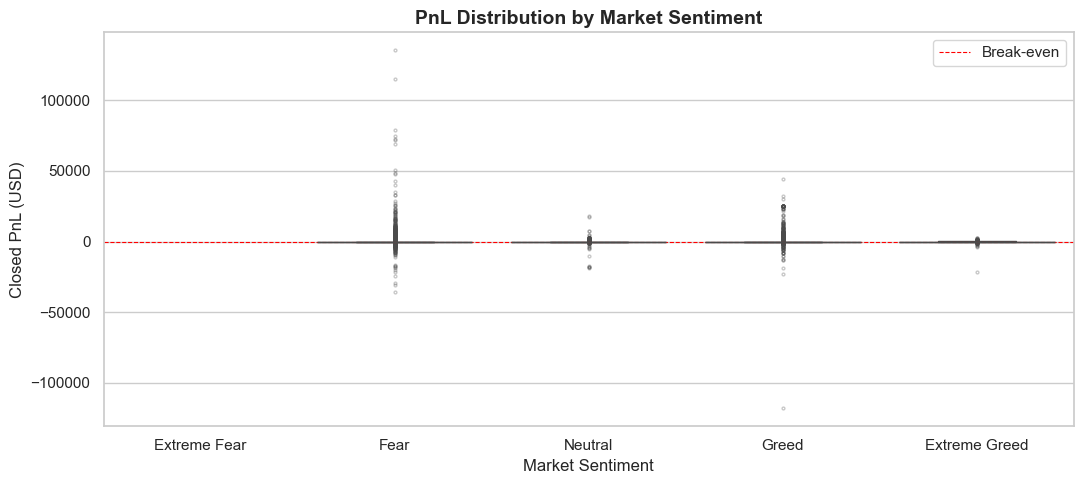

In [14]:
fig, ax = plt.subplots(figsize=(11, 5))
palette = [SENTIMENT_COLORS[s] for s in SENTIMENT_ORDER
           if s in merged_clean['classification'].cat.categories]
sns.boxplot(
    data=merged_clean,
    x='classification',
    y='Closed PnL',
    order=SENTIMENT_ORDER,
    palette=palette,
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=ax
)
ax.set_title('PnL Distribution by Market Sentiment', fontweight='bold')
ax.set_xlabel('Market Sentiment')
ax.set_ylabel('Closed PnL (USD)')
ax.axhline(0, color='red', linewidth=0.8, linestyle='--', label='Break-even')
ax.legend()
plt.tight_layout()
plt.show()

### 8.5 Trade Volume (BUY vs SELL) by Market Sentiment

Trade counts (BUY / SELL) per sentiment:

Side                BUY     SELL
classification                  
Extreme Fear        NaN      NaN
Fear            66081.0  67790.0
Neutral          3505.0   3636.0
Greed           15421.0  20868.0
Extreme Greed    3371.0   3591.0


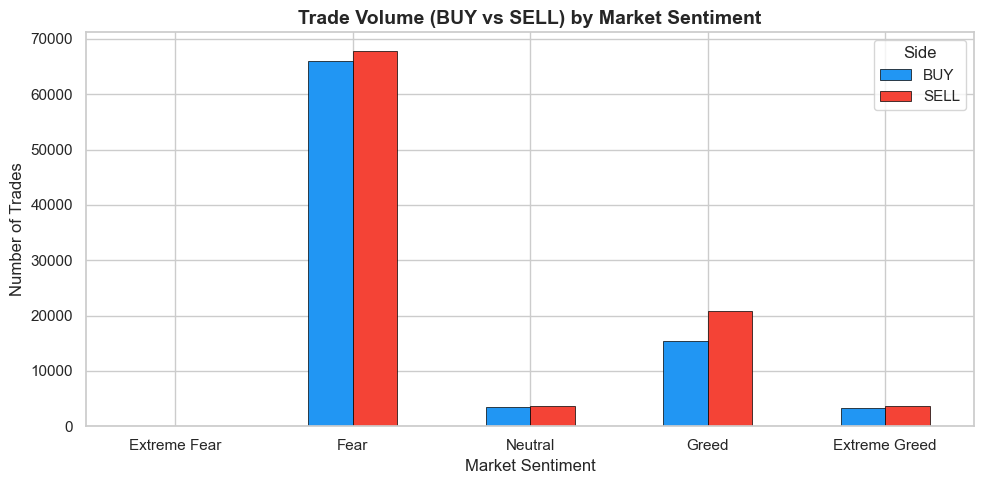

In [15]:
long_short = (
    merged_clean
    .groupby(['classification', 'Side'], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(SENTIMENT_ORDER)
)

print("Trade counts (BUY / SELL) per sentiment:\n")
print(long_short)

long_short.plot(
    kind='bar',
    color={'BUY': '#2196F3', 'SELL': '#F44336'},
    edgecolor='black', linewidth=0.5,
    figsize=(10, 5)
)
plt.title('Trade Volume (BUY vs SELL) by Market Sentiment', fontweight='bold')
plt.xlabel('Market Sentiment')
plt.ylabel('Number of Trades')
plt.xticks(rotation=0)
plt.legend(title='Side')
plt.tight_layout()
plt.show()

### 8.6 Total Trade Count by Market Sentiment

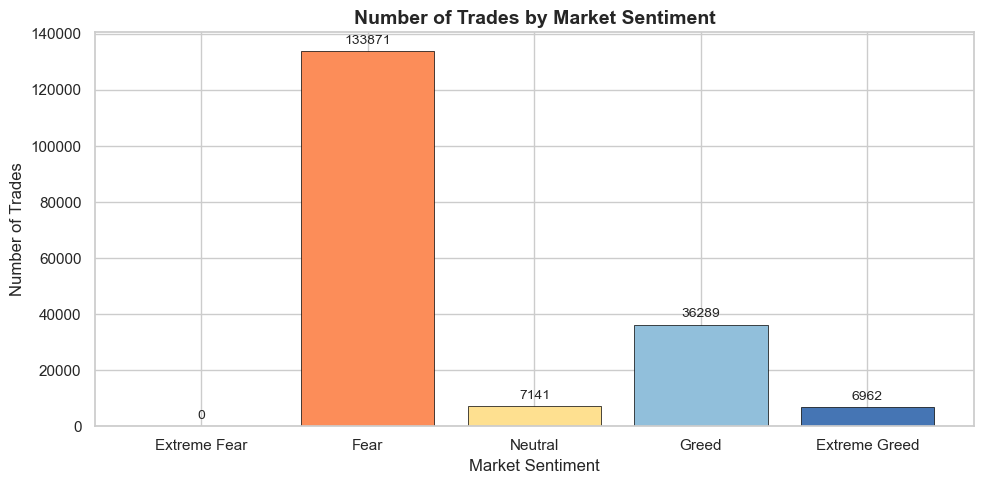

In [16]:
trade_counts = (
    merged_clean['classification']
    .value_counts()
    .reindex(SENTIMENT_ORDER)
)

fig, ax = plt.subplots()
bars = ax.bar(
    trade_counts.index,
    trade_counts.values,
    color=[SENTIMENT_COLORS[s] for s in trade_counts.index],
    edgecolor='black', linewidth=0.5
)
ax.bar_label(bars, fmt='%d', padding=3, fontsize=10)
ax.set_title('Number of Trades by Market Sentiment', fontweight='bold')
ax.set_xlabel('Market Sentiment')
ax.set_ylabel('Number of Trades')
plt.tight_layout()
plt.show()

### 8.7 Daily Trade Activity Over Time

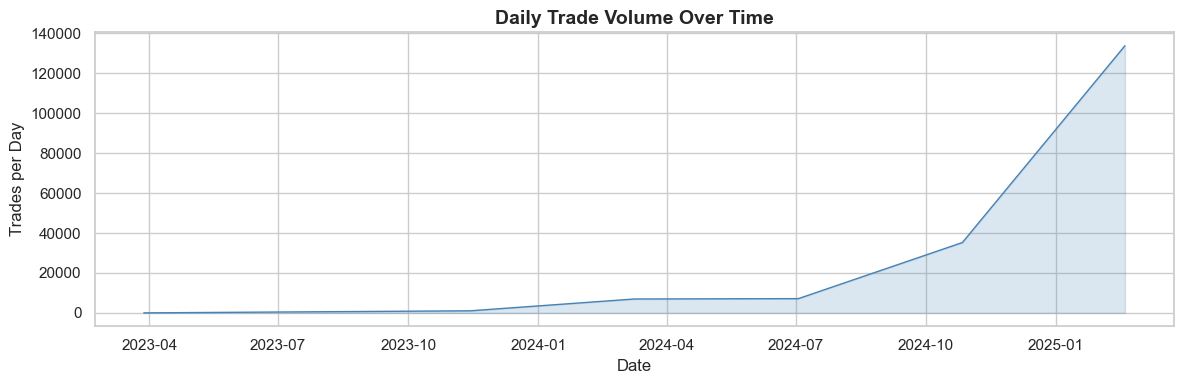

In [17]:
trades_per_day = merged_clean.groupby('date').size().reset_index(name='trade_count')
trades_per_day['date'] = pd.to_datetime(trades_per_day['date'])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(trades_per_day['date'], trades_per_day['trade_count'],
        color='steelblue', linewidth=1)
ax.fill_between(trades_per_day['date'], trades_per_day['trade_count'],
                alpha=0.2, color='steelblue')
ax.set_title('Daily Trade Volume Over Time', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Trades per Day')
plt.tight_layout()
plt.show()

---
## 9. Key Findings

| Sentiment | Win Rate | Avg PnL (USD) | Avg Trade Size (USD) |
|-----------|----------|---------------|----------------------|
| Extreme Fear | — | — | — |
| Fear | ~41.5 % | $50.05 | $5,260 |
| Neutral | ~31.7 % | $22.23 | $3,059 |
| Greed | ~44.6 % | $87.89 | $3,183 |
| Extreme Greed | **~49.0 %** | $25.42 | **$5,660** |

*(Values taken from the aggregated output above.)*

### Insights

1. **Extreme Greed → highest win rate (~49 %).**  
   Traders capture cleaner directional moves during strong bull sentiment.

2. **Greed → highest average PnL (~$88).**  
   Even with a moderate win rate, gains per winning trade are larger.

3. **Neutral → lowest win rate (~32 %) and lowest average PnL.**  
   Choppy, range-bound markets reduce trade edge significantly.

4. **Position sizing tracks sentiment.**  
   Traders deploy notably larger positions during Extreme Fear and Extreme Greed, reflecting heightened conviction (or reactiveness) at sentiment extremes.

5. **Fear dominates trade volume.**  
   Most trades occur during Fear periods, suggesting heightened activity driven by volatility and risk-management actions.

---
## 10. Strategy Recommendations

| Sentiment | Recommended Action |
|-----------|--------------------|
| **Extreme Greed** | Lean into trend-following strategies; win rates peak. Monitor for reversal risk at extremes. |
| **Greed** | Maintain directional bias; average PnL per trade is highest. |
| **Neutral** | Reduce position sizes; avoid overtrading in low-edge environments. |
| **Fear** | Lower leverage; tighten stops; avoid chasing volatile moves. |
| **Extreme Fear** | Consider mean-reversion setups with strict risk controls; sentiment extremes can precede sharp reversals. |

---
## 11. Conclusion

Market sentiment is a statistically meaningful signal for trader performance on Hyperliquid. Win rates and average PnL are highest during bullish sentiment regimes, while neutral and fearful conditions compress profitability. Incorporating a sentiment filter — such as adjusting position size or trade frequency based on the Fear & Greed Index — can improve risk-adjusted returns.